# 37.1 · Patch embeddings and positions

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain patch embeddings and positions using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[24 · PyTorch for Computer Vision](../../24-pytorch-for-computer-vision/README.md), [25 · Image Classification](../../25-image-classification/README.md). First read [38 attention primer](../../38-attention-mechanisms/theory/concepts.md); return here to build ViT.

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

A Vision Transformer turns an image into a sequence of patch tokens and lets tokens exchange information through attention. This changes the inductive assumptions used by a CNN. Read the attention primer in Chapter 38 before implementing the transformer block here; the directory numbering follows the requested catalog.

## 2. Intuition

Divide an image into non-overlapping patches, flatten each patch and project it into an embedding vector. A convolution with kernel and stride equal to the patch size performs the same shared projection. Position embeddings distinguish where tokens came from; otherwise attention alone does not encode the image grid order.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 37
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
N=(H/P)(W/P)
$$

H and W are image height and width, P square patch size and N the number of patch tokens when dimensions divide exactly. A 24×24 image with 6×6 patches produces 16 tokens.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
height, width, patch = 24, 24, 6
assert height % patch == width % patch == 0
tokens = (height // patch) * (width // patch)
assert tokens == 16
print(tokens)

16


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

TinyViT uses a patch projection, learned position embeddings, an encoder block, normalization, token averaging and a classifier. The source exposes each step instead of calling a pretrained model in the default notebook.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def vit(lesson, seed, amount):
    if lesson == 0:
        configure(seed)
        x, _, _ = shape_data(3, seed=seed)
        model = TinyViT()
        with torch.no_grad():
            tokens = model.patch(x).flatten(2).transpose(1, 2)
        return Result(
            "37 · Image patches become a token sequence",
            {"Input": x[0, 0].numpy(), "Patch token vectors": tokens[0].numpy()},
            metrics={
                "tokens_shape": list(tokens.shape),
                "patch_size": 6,
                "embedding_dimension": 24,
            },
        )
    model, history, x, y, pred = classification_experiment(
        seed, kind="vit", epochs=5, lr=0.003 * amount
    )
    return Result(
        "37 · Train a simplified vision transformer",
        {
            "Held-out image": x[0, 0].numpy(),
            "Confusion matrix": confusion_matrix(y, pred, labels=[0, 1, 2]),
        },
        curves={"Training CE": history},
        metrics={
            "held_out_accuracy": float((pred == y).float().mean()),
            "epochs": 5,
            "parameters": sum(p.numel() for p in model.parameters()),
        },
        notes="One encoder and mean pooling; no claim to reproduce a published ImageNet ViT result.",
    )

{
  "tokens_shape": [
    3,
    16,
    24
  ],
  "patch_size": 6,
  "embedding_dimension": 24
}



## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/models.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.models import TinyViT

display(Code(inspect.getsource(TinyViT), language="python"))

class TinyViT(nn.Module):
    def __init__(self, size=24, patch=6, dimension=24, classes=3):
        super().__init__()
        self.patch = nn.Conv2d(1, dimension, patch, stride=patch)
        self.position = nn.Parameter(torch.zeros(1, (size // patch) ** 2, dimension))
        layer = nn.TransformerEncoderLayer(
            dimension, 4, dim_feedforward=48, dropout=0.0, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=1, enable_nested_tensor=False)
        self.norm = nn.LayerNorm(dimension)
        self.head = nn.Linear(dimension, classes)

    def forward(self, x):
        tokens = self.patch(x).flatten(2).transpose(1, 2) + self.position
        return self.head(self.norm(self.encoder(tokens)).mean(1))

## 8. Experiment

Double the number of tokens and estimate attention-matrix growth before measuring memory. Compare the tiny CNN and ViT on the same synthetic split.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "tokens_shape": [
      3,
      16,
      24
    ],
    "patch_size": 6,
    "embedding_dimension": 24
  },
  "second_seed": {
    "tokens_shape": [
      3,
      16,
      24
    ],
    "patch_size": 6,
    "embedding_dimension": 24
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

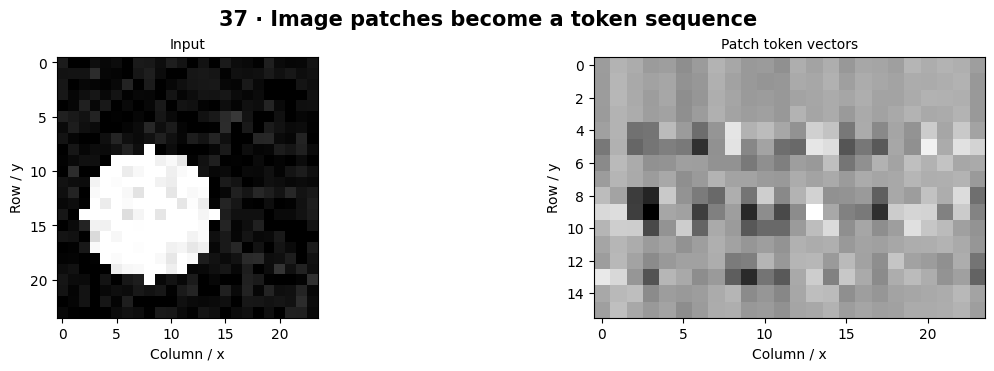

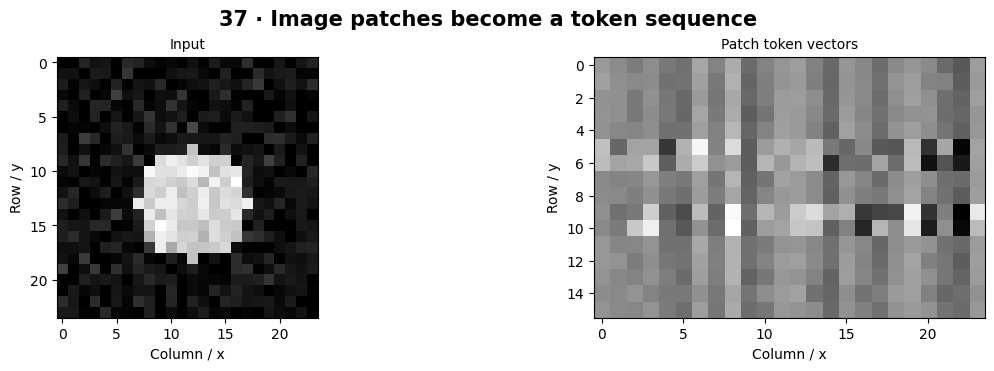

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Tiny Vision Transformer**. Implement small attention first, then a simplified ViT. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Reshape cannot replace a correct patch permutation. Pretrained position embeddings may need resizing when image resolution changes.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Double the number of tokens and estimate attention-matrix growth before measuring memory. Compare the tiny CNN and ViT on the same synthetic split.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Compare a small CNN and ViT under equal training budgets, with fixed splits and ablations for patch size and position embeddings.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Divide an image into non-overlapping patches, flatten each patch and project it into an embedding vector. A convolution with kernel and stride equal to the patch size performs the same shared projection. Position embeddings distinguish where tokens came from; otherwise attention alone does not encode the image grid order.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Transformer encoder mechanics** in this chapter.

[Primary reference](https://arxiv.org/abs/2010.11929) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)